In [84]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import torchvision

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [85]:
print(f'using device {device}')

using device cuda


In [86]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [87]:
train_loader = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=True, download=True, transform=transform),
    batch_size=128,
    shuffle=True
)
test_loadeer = torch.utils.data.DataLoader(
    datasets.CIFAR10('./data', train=False, download=True, transform=transform),
    batch_size=128,
    shuffle=True
)

Files already downloaded and verified
Files already downloaded and verified


In [88]:
learning_rate = 1e-3
num_epochs = 50
image_size = 32
channels = 3
latent_dim = 128
num_embedding = 512 
commitment_cost = 0.25 

In [ ]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embedding, embedding_dim):
        super(VQEmbedding, self).__init__()
        self.num_embedding = num_embedding
        self.embedding_dim = embedding_dim
        self.embedding = nn.Embedding(self.num_embedding, self.embedding_dim)
        self.embedding.weight.data.uniform_(-1/self.num_embedding, 1/self.num_embedding)

    def forward(self, x):
        b, c, h, w = x.shape
        z = x.permute(0, 2, 3, 1)
        z_flattened = z.reshape(b*h*w, self.embedding_dim)

        distances = torch.sum(z_flattened**2, dim=-1, keepdim=True) + torch.sum(self.embedding.weight.t()**2, dim=0, keepdim=True) - 2*torch.matmul(z_flattened, self.embedding.weight.t())

        encoding_indices = torch.argmin(distances, dim=-1)

        zq = self.embedding(encoding_indices)
        zq = zq.reshape(b, h, w, self.embedding_dim)
        zq = zq.permute(0, 3, 1, 2)

        loss = F.mse_loss(zq, x.detach()) + commitment_cost * F.mse_loss(zq.detach(), x)

        zq = x + (zq - x).detach()

        return zq, loss, encoding_indices

In [ ]:
class VQVAE(nn.Module):
    def __init__(self):
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, latent_dim, kernel_size=1)
        )
        self.vqe = VQEmbedding(num_embedding, latent_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 128, kernel_size=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        ze = self.encoder(x)
        zq, commitment_loss, _ = self.vqe(ze)
        x_recon = self.decoder(zq)
        return x_recon, commitment_loss


In [91]:
model = VQVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [92]:
def show_image(batch_of_tensors):
    images = batch_of_tensors[:4]
    images = (images * 0.5) + 0.5  
    grid_img = torchvision.utils.make_grid(images, nrow=2)
    plt.figure(figsize=(5, 5))
    plt.imshow(grid_img.permute(1, 2, 0))  
    plt.axis('off')
    plt.show()

Epoch 1/50: 100%|██████████| 391/391 [00:15<00:00, 24.75it/s, Loss=0.325]


Epoch [1/50] Average Loss: 0.0110


Epoch 2/50: 100%|██████████| 391/391 [00:16<00:00, 23.53it/s, Loss=0.165]


Epoch [2/50] Average Loss: 0.0020


Epoch 3/50: 100%|██████████| 391/391 [00:14<00:00, 27.29it/s, Loss=0.125]


...

Epoch [8/50] Average Loss: 0.0008


Epoch 9/50: 100%|██████████| 391/391 [00:13<00:00, 28.12it/s, Loss=0.113] 


Epoch [9/50] Average Loss: 0.0008


Epoch 10/50: 100%|██████████| 391/391 [00:16<00:00, 23.47it/s, Loss=0.122] 


Epoch [10/50] Average Loss: 0.0008


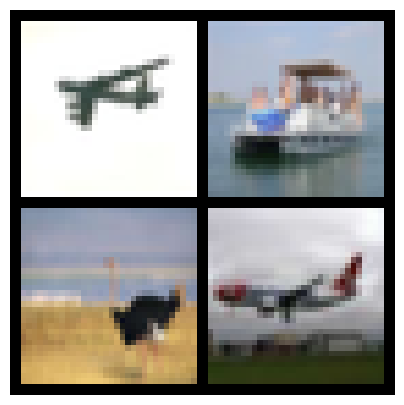

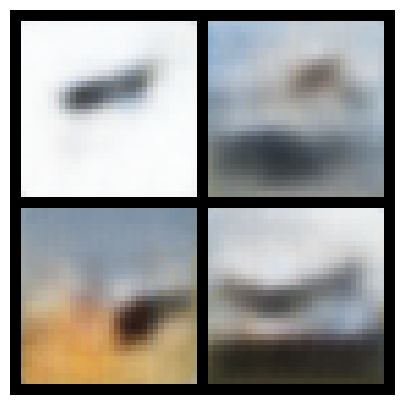

Epoch 11/50: 100%|██████████| 391/391 [00:18<00:00, 20.86it/s, Loss=0.0968]


Epoch [11/50] Average Loss: 0.0008


Epoch 12/50: 100%|██████████| 391/391 [00:17<00:00, 22.88it/s, Loss=0.102] 


Epoch [12/50] Average Loss: 0.0008


Epoch 13/50: 100%|██████████| 391/391 [00:14<00:00, 27.30it/s, Loss=0.107] 


...

Epoch [18/50] Average Loss: 0.0009


Epoch 19/50: 100%|██████████| 391/391 [00:13<00:00, 28.12it/s, Loss=0.109]


Epoch [19/50] Average Loss: 0.0009


Epoch 20/50: 100%|██████████| 391/391 [00:14<00:00, 26.87it/s, Loss=0.108]

Epoch [20/50] Average Loss: 0.0009


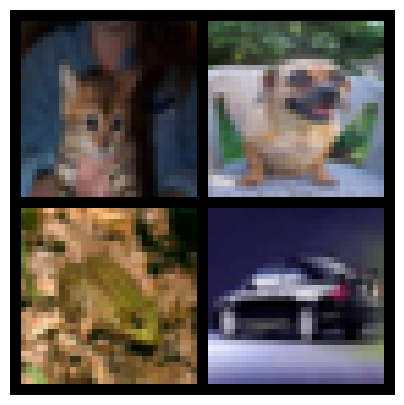

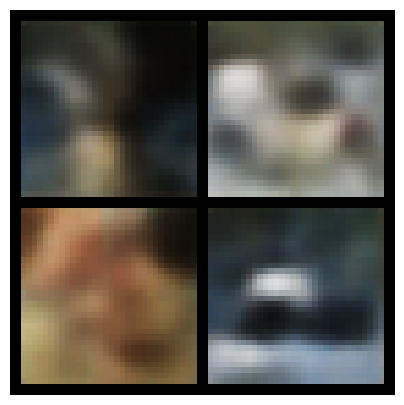

Epoch 21/50: 100%|██████████| 391/391 [00:14<00:00, 26.18it/s, Loss=0.115]


Epoch [21/50] Average Loss: 0.0009


Epoch 22/50: 100%|██████████| 391/391 [00:14<00:00, 26.85it/s, Loss=0.11] 


Epoch [22/50] Average Loss: 0.0009


Epoch 23/50: 100%|██████████| 391/391 [00:24<00:00, 15.68it/s, Loss=0.126]


...

Epoch [28/50] Average Loss: 0.0009


Epoch 29/50: 100%|██████████| 391/391 [00:32<00:00, 12.10it/s, Loss=0.117]


Epoch [29/50] Average Loss: 0.0009


Epoch 30/50: 100%|██████████| 391/391 [00:27<00:00, 14.46it/s, Loss=0.114]


Epoch [30/50] Average Loss: 0.0009


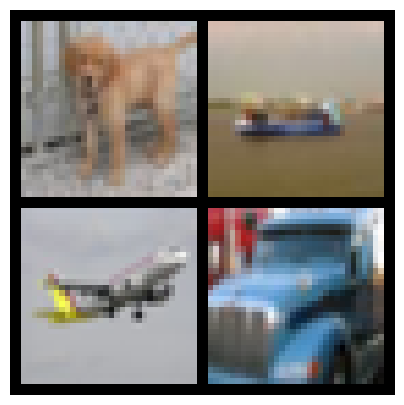

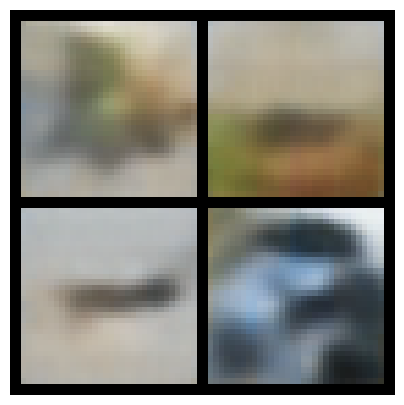

Epoch 31/50: 100%|██████████| 391/391 [00:24<00:00, 15.65it/s, Loss=0.117]


Epoch [31/50] Average Loss: 0.0009


Epoch 32/50: 100%|██████████| 391/391 [00:15<00:00, 25.11it/s, Loss=0.113] 


Epoch [32/50] Average Loss: 0.0009


Epoch 33/50: 100%|██████████| 391/391 [00:21<00:00, 18.60it/s, Loss=0.113] 


...

Epoch [38/50] Average Loss: 0.0009


Epoch 39/50: 100%|██████████| 391/391 [00:13<00:00, 29.51it/s, Loss=0.098] 


Epoch [39/50] Average Loss: 0.0009


Epoch 40/50: 100%|██████████| 391/391 [00:14<00:00, 26.44it/s, Loss=0.113]

Epoch [40/50] Average Loss: 0.0009


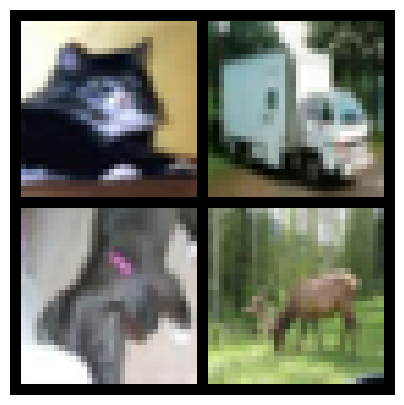

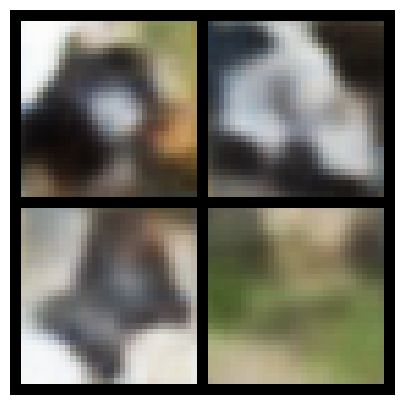

Epoch 41/50: 100%|██████████| 391/391 [00:13<00:00, 29.06it/s, Loss=0.118] 


Epoch [41/50] Average Loss: 0.0009


Epoch 42/50: 100%|██████████| 391/391 [00:14<00:00, 26.68it/s, Loss=0.102] 


Epoch [42/50] Average Loss: 0.0009


Epoch 43/50: 100%|██████████| 391/391 [00:15<00:00, 25.61it/s, Loss=0.11]  


...

Epoch [48/50] Average Loss: 0.0008


Epoch 49/50: 100%|██████████| 391/391 [00:14<00:00, 26.63it/s, Loss=0.113] 


Epoch [49/50] Average Loss: 0.0008


Epoch 50/50: 100%|██████████| 391/391 [00:14<00:00, 26.60it/s, Loss=0.104] 


Epoch [50/50] Average Loss: 0.0008


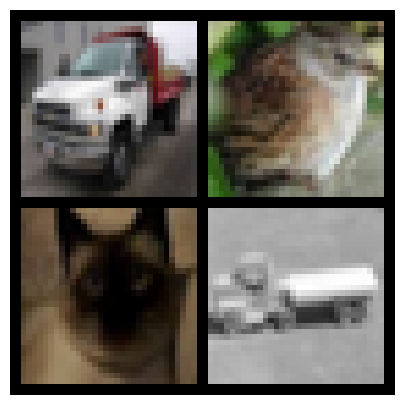

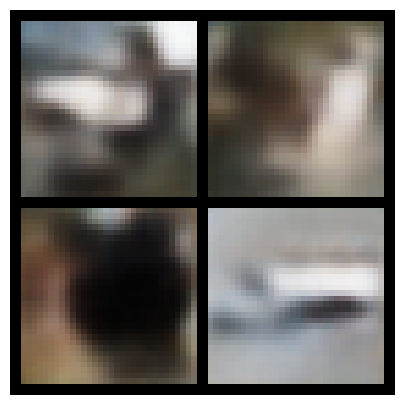

In [93]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    pbar = tqdm(enumerate(train_loader), total = len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, (data, _) in pbar:
        data = data.to(device)

        optimizer.zero_grad()
        recon_batch, vq_loss = model(data)
        loss = vq_loss + F.mse_loss(recon_batch, data)
        loss.backward()

        train_loss += loss.item()
        optimizer.step()

        pbar.set_postfix({'Loss': loss.item()})
    
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            recon_batch, _ = model(data)
            show_image(data.cpu())
            show_image(recon_batch.cpu())